In [2]:
import os, sys
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
import torch
import wandb
from skimage.transform import resize
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

In [3]:
PROJECT_ROOT = "/share/castor/home/e2406751/Superresolution-TIR"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
 
from scripts.utils.dataset import SRDataset
from scripts.models.edsr import EDSRModule
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [20]:
# Replace <run_id> with your actual run ID e.g. xmujl7dh
api   = wandb.Api()
art   = api.artifact("ogalloethel-university-of-south-brittany/TIR_sisr/model-yxrgylup:best")
local = art.download("/tmp/ckpt")
ckpt_path = next(os.path.join(local, f) for f in os.listdir(local) if f.endswith(".ckpt"))
print(f"Checkpoint: {ckpt_path}")
 
model = EDSRModule.load_from_checkpoint(ckpt_path, map_location=device)
model.eval()

wandb:   1 of 1 files downloaded.  


Checkpoint: /tmp/ckpt/model.ckpt
[INFO] Loading pretrained weights: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[INFO] Matched 68 / 74 layers


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


EDSRModule(
  (body): EDSR(
    (conv_first): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (body): Sequential(
      (0): ResidualBlockNoBN(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU(inplace=True)
      )
      (1): ResidualBlockNoBN(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU(inplace=True)
      )
      (2): ResidualBlockNoBN(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU(inplace=True)
      )
      (3): ResidualBlockNoBN(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, ker

In [21]:
with open("data/full_metadata.json") as f:
    all_meta = json.load(f)
 
metadata = pd.DataFrame(all_meta)
test_df  = metadata[metadata["split"] == "test"].reset_index(drop=True)
print(f"Test patches: {len(test_df)}")

ds = SRDataset(test_df, mean=model.hparams.mean, std=model.hparams.std, patch_size=48, is_train=False)

Test patches: 11


In [22]:
# Change PATCH_IDX to inspect different patches
PATCH_IDX = 0
print(f"Patch: {test_df.iloc[PATCH_IDX]['patch_id']}")
 
lr_t, hr_t, mask_t = ds[PATCH_IDX]
 
with torch.no_grad():
    sr_t = model(lr_t.unsqueeze(0).to(device))
 
# Denormalize everything to °C
sr = model.denormalize(sr_t).squeeze().cpu().numpy()
hr = model.denormalize(hr_t.unsqueeze(0)).squeeze().numpy()
lr = model.denormalize(lr_t.unsqueeze(0)).squeeze().numpy()
mk = mask_t.squeeze().numpy() > 0.5
 
# Resize mask to LR resolution for LR display
lr_mask = resize(mk, lr.shape, order=0, preserve_range=True) > 0.5
 
# Mask nodata regions
hr_disp = np.where(mk,      hr, np.nan)
sr_disp = np.where(mk,      sr, np.nan)
lr_disp = np.where(lr_mask, lr, np.nan)
 
# Metrics on valid region
sr_t_den   = model.denormalize(sr_t)
hr_t_den   = model.denormalize(hr_t.unsqueeze(0).to(device))
mask_t_dev = mask_t.unsqueeze(0).to(device)
 
sr_crop, mask_crop = model.crop_to_valid_bbox(sr_t_den, mask_t_dev)
hr_crop, _         = model.crop_to_valid_bbox(hr_t_den, mask_t_dev)
 
device = sr_crop.device  # or just `device` from your script

psnr_metric = PeakSignalNoiseRatio(data_range=60.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=60.0).to(device)

psnr_val = psnr_metric(sr_crop * mask_crop, hr_crop * mask_crop).item()
ssim_val = ssim_metric(sr_crop, hr_crop).item()
mae_val  = float(np.abs(sr_disp[mk] - hr_disp[mk]).mean())
 
print(f"PSNR : {psnr_val:.2f} dB")
print(f"SSIM : {ssim_val:.3f}")
print(f"MAE  : {mae_val:.4f} °C")

Patch: BRC_2022_1.tif
PSNR : 30.33 dB
SSIM : 0.867
MAE  : 2.5943 °C


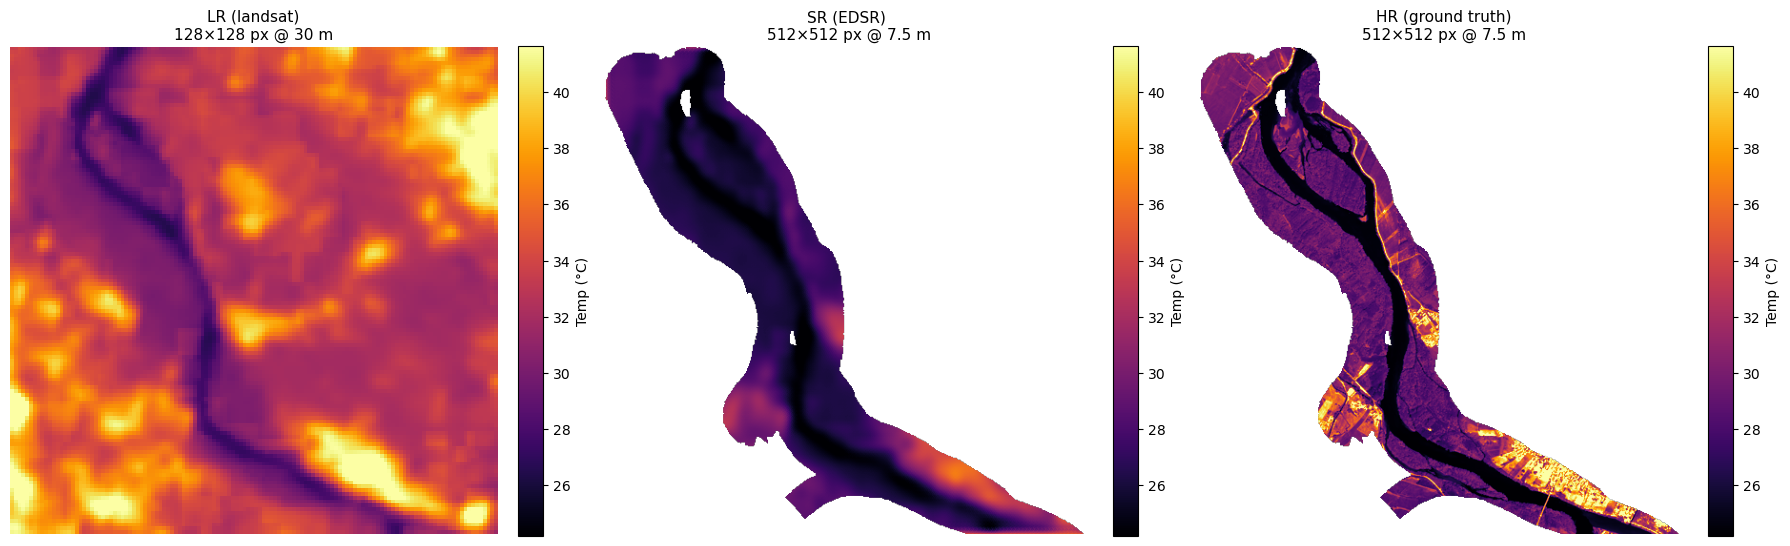

In [23]:
# vmin and vmax from HR
vmin = np.nanpercentile(hr_disp, 2)
vmax = np.nanpercentile(hr_disp, 98)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# LR: show full scene
lr_disp = lr  # no masking needed

# SR: can show full model output
# sr_disp = sr  # optionally mask to HR region if you want
sr_disp = np.where(mk,      sr, np.nan)

# HR: can mask invalid pixels if you like
hr_disp = np.where(mk, hr, np.nan)

panels = [
    (lr_disp, f"LR (landsat)\n{lr.shape[1]}×{lr.shape[0]} px @ 30 m"),
    (sr_disp, f"SR (EDSR) \n{sr.shape[1]}×{sr.shape[0]} px @ 7.5 m"),
    (hr_disp, f"HR (ground truth)\n{hr.shape[1]}×{hr.shape[0]} px @ 7.5 m"),
]
 
for ax, (img, title) in zip(axes, panels):
    im = ax.imshow(img, cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Temp (°C)")
 
plt.tight_layout()
plt.show()

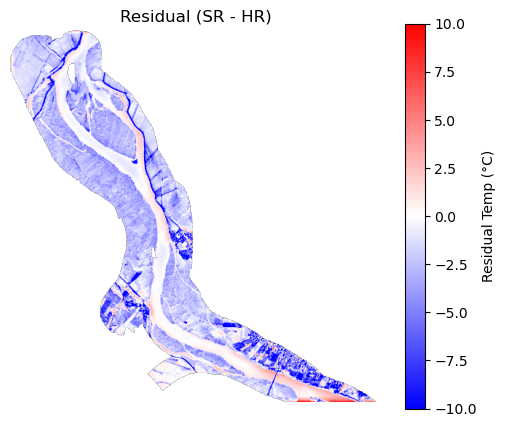

In [24]:
residual = sr_disp - hr_disp

plt.figure(figsize=(6, 5))
plt.imshow(residual, cmap="bwr", vmin=-10, vmax=10)
plt.colorbar(label="Residual Temp (°C)")
plt.title("Residual (SR - HR)", fontsize=12)
plt.axis("off")
plt.show()

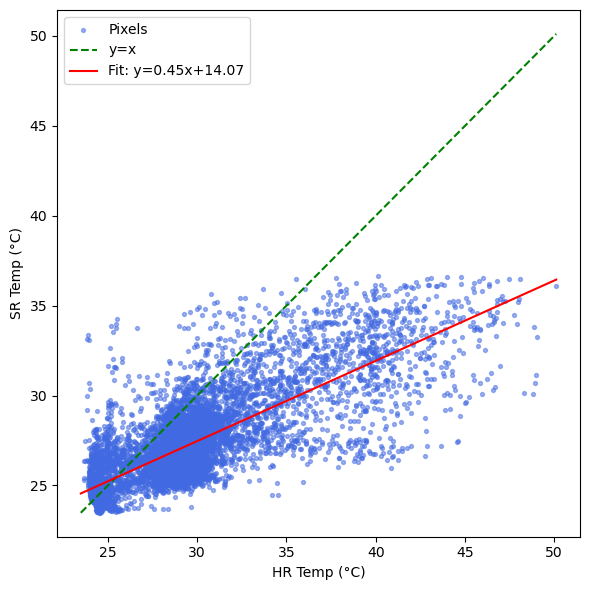

In [25]:
# Flatten valid pixels
hr_valid = hr_disp[mk].flatten()
sr_valid = sr_disp[mk].flatten()

# Sample pixels for plotting
num_samples = min(len(hr_valid), 10000)
indices = np.random.choice(len(hr_valid), num_samples, replace=False)
hr_sample = hr_valid[indices]
sr_sample = sr_valid[indices]

# Scatter plot
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(hr_sample, sr_sample, s=8, alpha=0.5, color='royalblue', label='Pixels')

# Ideal prediction line
t_min = min(hr_sample.min(), sr_sample.min())
t_max = max(hr_sample.max(), sr_sample.max())
ax.plot([t_min, t_max], [t_min, t_max], 'g--', lw=1.5, label='y=x')

# Regression line
coeffs = np.polyfit(hr_sample, sr_sample, 1)
x_line = np.array([t_min, t_max])
ax.plot(x_line, np.polyval(coeffs, x_line), 'r-', lw=1.5, label=f'Fit: y={coeffs[0]:.2f}x+{coeffs[1]:.2f}')


ax.set_xlabel("HR Temp (°C)")
ax.set_ylabel("SR Temp (°C)")
ax.legend()
plt.tight_layout()
plt.show()

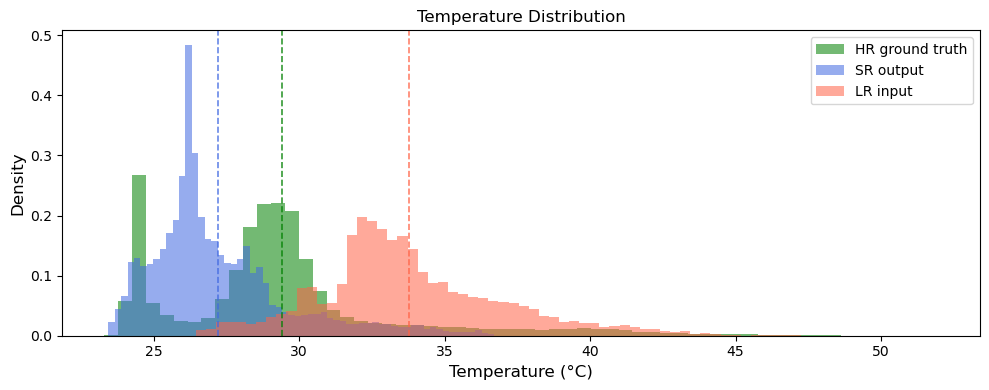

In [26]:
# A blurry model will have SR std << HR std — distribution too narrow
# A good model will have SR std ≈ HR std and similar shape
hr_valid = hr_disp[mk].flatten()
sr_valid = sr_disp[mk].flatten()
# lr_valid = lr_disp[lr_mask].flatten()
lr_valid = lr_disp.flatten()  # no masking needed
 
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hr_valid, bins=60, alpha=0.55, color="green",     label="HR ground truth", density=True)
ax.hist(sr_valid, bins=60, alpha=0.55, color="royalblue", label="SR output",       density=True)
ax.hist(lr_valid, bins=60, alpha=0.55, color="tomato",    label="LR input",        density=True)
 
# Vertical mean lines
for val, color in [(hr_valid.mean(), "green"),
                   (sr_valid.mean(), "royalblue"),
                   (lr_valid.mean(), "tomato")]:
    ax.axvline(val, color=color, linestyle="--", lw=1.2, alpha=0.8)
 
ax.set_xlabel("Temperature (°C)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"Temperature Distribution", fontsize=12)
ax.legend(fontsize=10)
 
# Std annotation — key diagnostic for blurriness
# textstr = (f"HR  std: {hr_valid.std():.3f} °C\n"
#            f"SR  std: {sr_valid.std():.3f} °C\n"
#            f"LR  std: {lr_valid.std():.3f} °C")
# ax.text(0.98, 0.97, textstr, transform=ax.transAxes,
#         fontsize=9, va="top", ha="right",
#         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
 
plt.tight_layout()
plt.show()

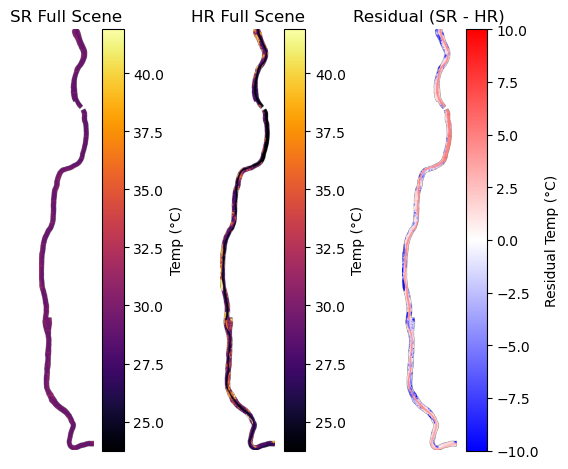

In [19]:
# viz SR and HR full scene
with rasterio.open('/share/home/e2406751/Superresolution-TIR/results/SR_images/SR_DZM_2023.tif') as src:
    nodata = src.nodata
    sr_full = src.read(1).astype(np.float32)

with rasterio.open('/share/home/e2406751/Superresolution-TIR/results/SR_images/HR_reassembled_DZM_2023.tif') as src:
    nodata = src.nodata
    hr_full = src.read(1).astype(np.float32)


#mask nodata regions if needed (assuming nodata is represented by zeros or a specific value)
# nodata_value = -99999  # change if your nodata is different
sr_full_masked = np.where(sr_full == nodata, np.nan, sr_full)
hr_full_masked = np.where(hr_full == nodata, np.nan, hr_full)

residual = sr_full_masked - hr_full_masked


#plt.figure(figsize=(18, 8))
plt.subplot(1, 3, 1)
plt.imshow(sr_full_masked, cmap="inferno", vmin=vmin, vmax=vmax)
plt.title("SR Full Scene", fontsize=12)
plt.axis("off")
plt.colorbar(label="Temp (°C)")

plt.subplot(1, 3, 2)
plt.imshow(hr_full_masked, cmap="inferno", vmin=vmin, vmax=vmax)   
plt.title("HR Full Scene", fontsize=12)
plt.axis("off")
plt.colorbar(label="Temp (°C)")

plt.subplot(1, 3, 3)
plt.imshow(residual, cmap="bwr", vmin=-10, vmax=10)
plt.colorbar(label="Residual Temp (°C)")
plt.title("Residual (SR - HR)", fontsize=12)
plt.axis("off")

plt.tight_layout()
plt.show()

SR  range : 19.38 – 43.93 °C
HR  range : 9.06 – 71.19 °C
vmin/vmax : 24.78 / 40.16


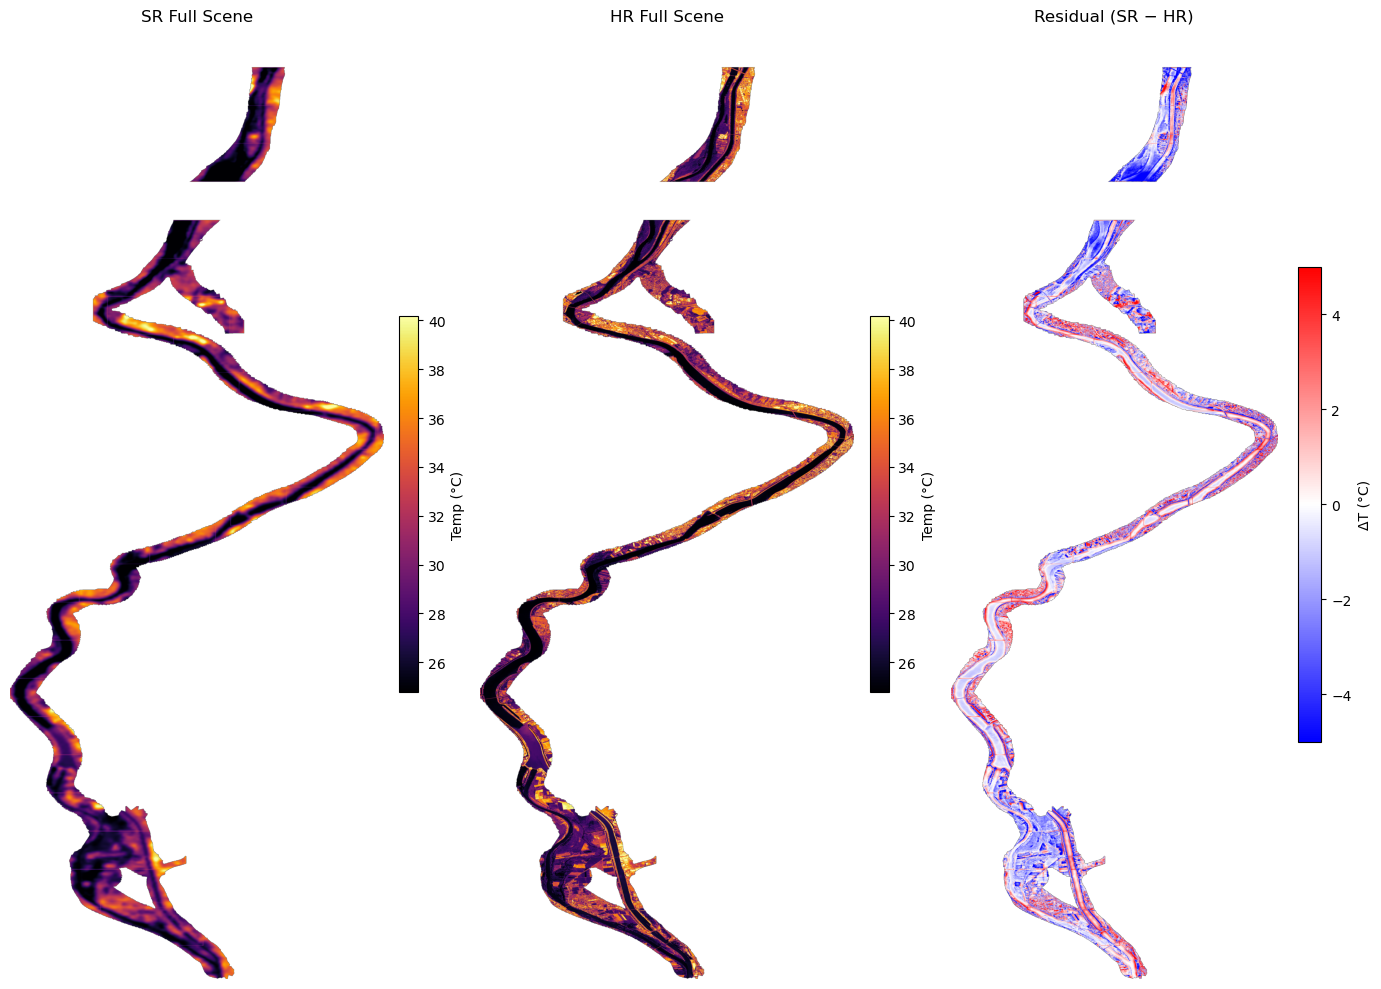

In [23]:

sr_path = "results/SR_images/SR_PDR_2023.tif"
hr_path = "results/SR_images/HR_reassembled_PDR_2023.tif"

with rasterio.open(sr_path) as src:
    sr = src.read(1).astype(np.float32)
    sr_nodata = src.nodata

with rasterio.open(hr_path) as src:
    hr = src.read(1).astype(np.float32)
    hr_nodata = src.nodata

# Mask
sr = np.where(sr == sr_nodata, np.nan, sr)
hr = np.where(hr == hr_nodata, np.nan, hr)
residual = sr - hr

# Stats from valid pixels only
vmin = np.nanpercentile(hr, 2)
vmax = np.nanpercentile(hr, 98)

print(f"SR  range : {np.nanmin(sr):.2f} – {np.nanmax(sr):.2f} °C")
print(f"HR  range : {np.nanmin(hr):.2f} – {np.nanmax(hr):.2f} °C")
print(f"vmin/vmax : {vmin:.2f} / {vmax:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 10))

axes[0].imshow(sr, cmap="inferno", vmin=vmin, vmax=vmax, aspect="auto")
axes[0].set_title("SR Full Scene")
axes[0].axis("off")
plt.colorbar(mappable=axes[0].images[0], ax=axes[0], label="Temp (°C)", fraction=0.046, pad=0.04)

axes[1].imshow(hr, cmap="inferno", vmin=vmin, vmax=vmax, aspect="auto")
axes[1].set_title("HR Full Scene")
axes[1].axis("off")
plt.colorbar(mappable=axes[1].images[0], ax=axes[1], label="Temp (°C)", fraction=0.046, pad=0.04)

im = axes[2].imshow(residual, cmap="bwr", vmin=-5, vmax=5, aspect="auto")
axes[2].set_title("Residual (SR − HR)")
axes[2].axis("off")

plt.colorbar(im, ax=axes[2], label="ΔT (°C)", shrink=0.5)
plt.tight_layout()
plt.show()

SR  range : 26.65 – 34.99 °C
HR  range : 19.92 – 79.43 °C
vmin/vmax : 23.76 / 41.89
Residual limits : -11.46 / 11.46


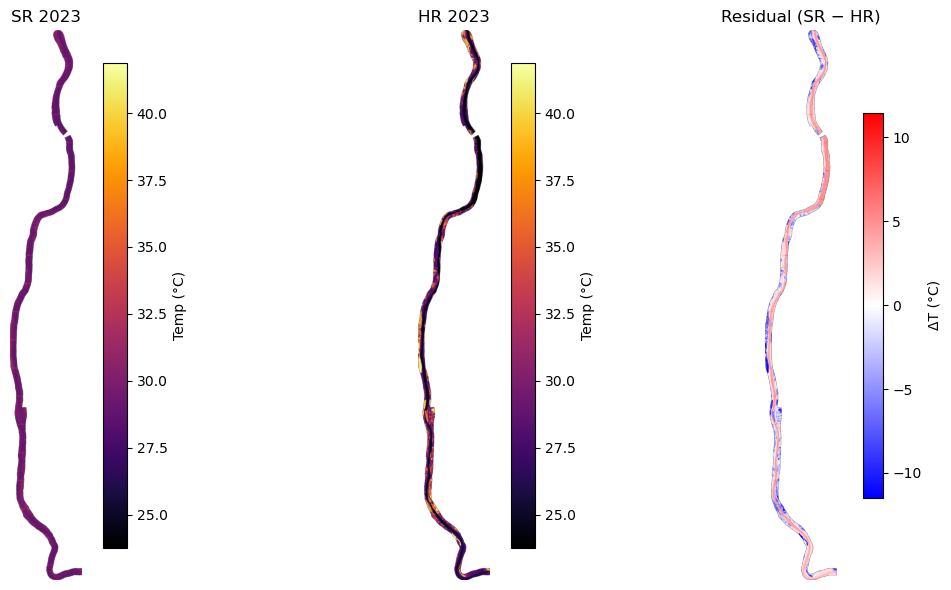

In [33]:
# Paths
sr_path = "results/SR_images/SR_DZM_2023.tif"
hr_path = "results/SR_images/HR_reassembled_DZM_2023.tif"

# Helper function
def load_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata
    return np.where(arr == nodata, np.nan, arr)

# Load data
sr = load_raster(sr_path)
hr = load_raster(hr_path)

# Residual (safe masking)
residual = np.where(np.isnan(sr) | np.isnan(hr), np.nan, sr - hr)

# Temperature scaling (robust)
vmin = np.nanpercentile(hr, 2)
vmax = np.nanpercentile(hr, 98)

# Dynamic residual scaling (symmetric)
res_valid = residual[~np.isnan(residual)]
lim = np.percentile(np.abs(res_valid), 98)
vmin_res, vmax_res = -lim, lim

# Stats
print(f"SR  range : {np.nanmin(sr):.2f} – {np.nanmax(sr):.2f} °C")
print(f"HR  range : {np.nanmin(hr):.2f} – {np.nanmax(hr):.2f} °C")
print(f"vmin/vmax : {vmin:.2f} / {vmax:.2f}")
print(f"Residual limits : {vmin_res:.2f} / {vmax_res:.2f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# SR
im0 = axes[0].imshow(sr, cmap="inferno", vmin=vmin, vmax=vmax)
axes[0].set_title("SR 2023")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], label="Temp (°C)", fraction=0.046, pad=0.04)

# HR
im1 = axes[1].imshow(hr, cmap="inferno", vmin=vmin, vmax=vmax)
axes[1].set_title("HR 2023")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], label="Temp (°C)", fraction=0.046, pad=0.04)

# Residual
im2 = axes[2].imshow(residual, cmap="bwr", vmin=vmin_res, vmax=vmax_res)
axes[2].set_title("Residual (SR − HR)")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], label="ΔT (°C)", shrink=0.7)

plt.tight_layout()
plt.show()

BRC 2023:
SR  range : 21.80 – 40.76 °C
HR  range : 1.22 – 131.17 °C

BRC 2022:
SR  range : 22.78 – 41.24 °C
HR  range : 20.03 – 60.39 °C

Shared vmin/vmax : 21.26 / 42.71
Residual limits  : -10.62 / 10.62


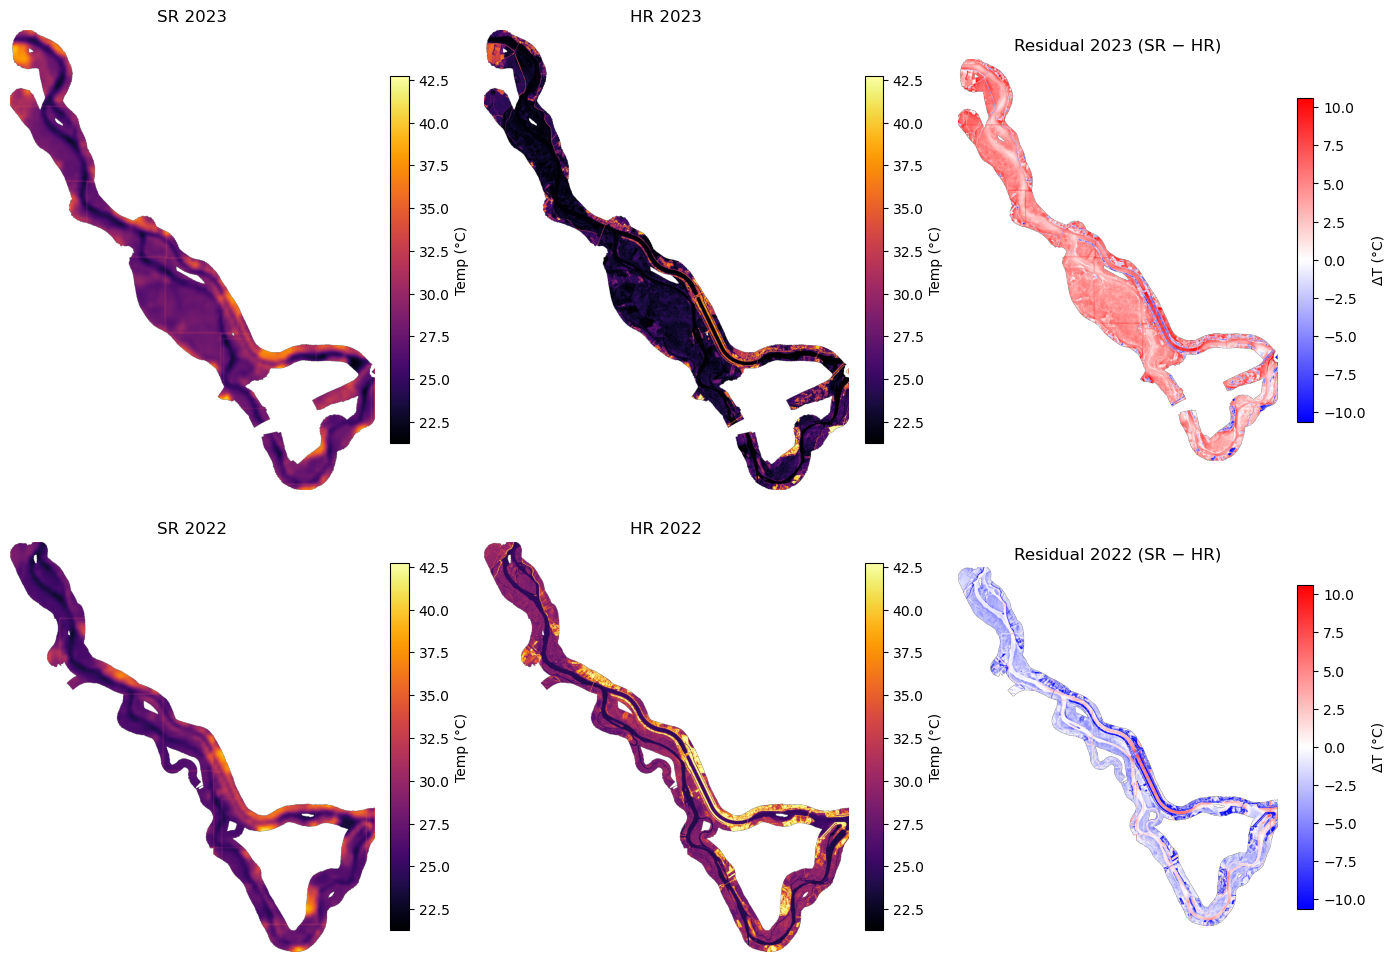

In [32]:
# Paths
sr_path1 = "results/SR_images/SR_BRC_2023.tif"
sr_path2 = "results/SR_images/SR_BRC_2022.tif"
hr_path1 = "results/SR_images/HR_reassembled_BRC_2023.tif"
hr_path2 = "results/SR_images/HR_reassembled_BRC_2022.tif"

# Helper function
def load_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata
    return np.where(arr == nodata, np.nan, arr)

# Load data
sr1 = load_raster(sr_path1)
hr1 = load_raster(hr_path1)
sr2 = load_raster(sr_path2)
hr2 = load_raster(hr_path2)

# Residuals (safe masking)
residual1 = np.where(np.isnan(sr1) | np.isnan(hr1), np.nan, sr1 - hr1)
residual2 = np.where(np.isnan(sr2) | np.isnan(hr2), np.nan, sr2 - hr2)

# Shared temperature scale (better comparison)
combined_hr = np.concatenate([hr1.flatten(), hr2.flatten()])
combined_hr = combined_hr[~np.isnan(combined_hr)]

vmin = np.percentile(combined_hr, 2)
vmax = np.percentile(combined_hr, 98)

# Dynamic residual scaling (symmetric)
res_all = np.concatenate([residual1.flatten(), residual2.flatten()])
res_all = res_all[~np.isnan(res_all)]
lim = np.percentile(np.abs(res_all), 98)

vmin_res, vmax_res = -lim, lim

# Print stats
print("BRC 2023:")
print(f"SR  range : {np.nanmin(sr1):.2f} – {np.nanmax(sr1):.2f} °C")
print(f"HR  range : {np.nanmin(hr1):.2f} – {np.nanmax(hr1):.2f} °C")

print("\nBRC 2022:")
print(f"SR  range : {np.nanmin(sr2):.2f} – {np.nanmax(sr2):.2f} °C")
print(f"HR  range : {np.nanmin(hr2):.2f} – {np.nanmax(hr2):.2f} °C")

print(f"\nShared vmin/vmax : {vmin:.2f} / {vmax:.2f}")
print(f"Residual limits  : {vmin_res:.2f} / {vmax_res:.2f}")

# Plot
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# ---- 2023 ----
im0 = axes[0, 0].imshow(sr1, cmap="inferno", vmin=vmin, vmax=vmax)
axes[0, 0].set_title("SR 2023")
axes[0, 0].axis("off")
plt.colorbar(im0, ax=axes[0, 0], label="Temp (°C)", fraction=0.046, pad=0.04)

im1 = axes[0, 1].imshow(hr1, cmap="inferno", vmin=vmin, vmax=vmax)
axes[0, 1].set_title("HR 2023")
axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], label="Temp (°C)", fraction=0.046, pad=0.04)

im2 = axes[0, 2].imshow(residual1, cmap="bwr", vmin=vmin_res, vmax=vmax_res)
axes[0, 2].set_title("Residual 2023 (SR − HR)")
axes[0, 2].axis("off")
plt.colorbar(im2, ax=axes[0, 2], label="ΔT (°C)", shrink=0.7)

# ---- 2022 ----
im3 = axes[1, 0].imshow(sr2, cmap="inferno", vmin=vmin, vmax=vmax)
axes[1, 0].set_title("SR 2022")
axes[1, 0].axis("off")
plt.colorbar(im3, ax=axes[1, 0], label="Temp (°C)", fraction=0.046, pad=0.04)

im4 = axes[1, 1].imshow(hr2, cmap="inferno", vmin=vmin, vmax=vmax)
axes[1, 1].set_title("HR 2022")
axes[1, 1].axis("off")
plt.colorbar(im4, ax=axes[1, 1], label="Temp (°C)", fraction=0.046, pad=0.04)

im5 = axes[1, 2].imshow(residual2, cmap="bwr", vmin=vmin_res, vmax=vmax_res)
axes[1, 2].set_title("Residual 2022 (SR − HR)")
axes[1, 2].axis("off")
plt.colorbar(im5, ax=axes[1, 2], label="ΔT (°C)", shrink=0.7)

plt.tight_layout()
plt.show()